# Hydrological Time Series Analysis for CAMELS-RU

## Comprehensive Analysis Workflow

This notebook performs:
1. **Data Loading**: Read geographical clustering results and discharge time series
2. **Hydrological Clustering**: Identify hydrological regime types based on discharge patterns
3. **Time Series Analysis**: Calculate comprehensive metrics for each gauge (period-based approach)
4. **Trend Analysis**: Detect monotonic trends using Mann-Kendall and Sen's slope estimator
5. **Comparative Analysis**: Compare hydrological characteristics across geographical clusters
6. **Visualization**: Create publication-quality plots and summary tables

**Dataset**: CAMELS-RU discharge time series (2008-2023)  
**Geographical Clusters**: 15 clusters based on HydroATLAS physiographic attributes  
**Analysis Period**: 15 years of daily discharge data  
**Methodology**: Non-parametric statistics, hierarchical clustering (Ward's method)

In [ ]:
# Import standard libraries
from collections import OrderedDict
from pathlib import Path
import re
import sys
import warnings

# Import scientific computing libraries
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

# Add project root to path
sys.path.append("../")

# Import project-specific modules# Get color and marker lists for trend categories
from src.plots.continuous_maps import russia_continuous_multiplot
from src.plots.maps import russia_plots
from src.static.hydro_atlas_analysis import (
    get_cluster_colors,
    get_cluster_markers,
    get_marker_size_corrections,
)
from src.timeseries_stats.trends import TrendAnalysis
from src.utils.logger import setup_logger

# Configure logger
logger = setup_logger("hydrological_final", log_file="../logs/hydrological_analysis.log")

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

logger.info("Imports complete. Starting hydrological analysis workflow.")


2025-10-10 15:56:36 | INFO     | camels_ru | hydrological_final | ℹ️  Imports complete. Starting hydrological analysis workflow.


## 1. Data Loading

### 1.1 Load Geographical Clustering Results

Load pre-computed geographical clusters based on HydroATLAS physiographic attributes (15 clusters using Ward's hierarchical clustering).

In [23]:
# Load geographical clustering results
geo_clusters = pd.read_csv(
    "../results/geo_gauge_cluster_analysis_15_detailed.csv",
    index_col="gauge_id",
    dtype={"gauge_id": str},
)

# Extract cluster assignment
geo_cluster_info = geo_clusters[["cluster_id", "cluster_name"]].copy()
geo_cluster_info.rename(
    columns={"cluster_id": "geo_cluster_id", "cluster_name": "geo_cluster_name"}, inplace=True
)

print(f"Loaded geographical clustering for {len(geo_cluster_info)} gauges")
print(f"Number of geographical clusters: {geo_cluster_info['geo_cluster_id'].nunique()}")
print("\nGeographical cluster distribution:")
print(geo_cluster_info["geo_cluster_name"].value_counts())

Loaded geographical clustering for 2251 gauges
Number of geographical clusters: 15

Geographical cluster distribution:
geo_cluster_name
Forested (88.8%) / Snow-dominated       480
Forested (84.1%) / Karst                253
Forested (57.4%)                        242
Lowland (228m) / Moderate (493mm/yr)    238
Forested (68.7%) / Sandy                182
Cropland (64.0%) / Clay-rich            179
Sandy / Snow-dominated                  159
Permafrost (88.0%) / Snow-dominated     110
Forested (77.9%) / Permafrost           105
Forested (78.8%) / High-PET              67
Highland (2215m) / Deep-GW               63
Silty / Snow-dominated                   59
Karst (82.7%) / Clay-rich                47
Snow-dominated (57.9%)                   46
Protected (81.7%) / Karst                21
Name: count, dtype: int64


### 1.2 Load Spatial Data and Filter High-Quality Gauges

In [3]:
# Identify gauges with high-quality discharge data
proper_dis = list({i.stem for i in Path("../data/HydroFiles/Discharge").rglob("decent/*.csv")})

# Load watershed geometries
ws = gpd.read_file("../data/Geometry/WatershedGeomCAMELS.gpkg")
ws.set_index("gauge_id", inplace=True)

# Filter watersheds: only high-quality data and area < 50,000 km²
ws = ws.loc[[ind for ind in ws.index if ind in proper_dis], :]
ws = ws.loc[ws["area"] < 50000, :]

# Load gauge point geometries
gauge = gpd.read_file("../data/Geometry/GaugeGeomCAMELS.gpkg")
gauge.set_index("gauge_id", inplace=True)
gauge = gauge.loc[ws.index, :]

# Load basemap for visualization
basemap_data = gpd.read_file("../data/Geometry/basemap.gpkg")

### 1.3 Load Discharge Time Series

Load full discharge time series for clustering and metrics calculation.

In [4]:
# Load discharge time series for all gauges
discharge_data = {}
dis_column = "q_mm_day"

for gauge_id in ws.index:
    try:
        partial_path = Path(f"../data/HydroFiles/Discharge/partial/decent/{gauge_id}.csv")
        full_path = Path(f"../data/HydroFiles/Discharge/full/decent/{gauge_id}.csv")

        if partial_path.exists():
            df = pd.read_csv(partial_path, parse_dates=True, index_col="date")
        elif full_path.exists():
            df = pd.read_csv(full_path, parse_dates=True, index_col="date")
        else:
            logger.warning(f"Missing discharge file for gauge {gauge_id}")
            continue

        discharge_data[gauge_id] = df[[dis_column]].squeeze()

    except Exception as e:
        logger.error(f"Error loading discharge for {gauge_id}: {e}")
        continue

## 2. Hydrological Clustering Based on Discharge Patterns

### 2.1 Prepare Normalized Seasonal Patterns

Calculate median seasonal cycle (366-day hydrograph) and normalize for clustering.

In [5]:
# Calculate median seasonal cycle for each gauge
q_df = {}

for gauge_id in discharge_data.keys():
    try:
        ts = discharge_data[gauge_id]
        # Group by day of year and take median across all years
        seasonal_cycle = ts.groupby([ts.index.month, ts.index.day]).median().values
        q_df[gauge_id] = seasonal_cycle

    except Exception as e:
        logger.error(f"Error calculating seasonal cycle for {gauge_id}: {e}")
        continue

# Convert to DataFrame (rows=days, columns=gauges)
q_df = pd.DataFrame.from_dict(q_df, orient="columns")

# Filter out gauges with extreme outliers (max > 90 mm/day)
q_df = q_df.loc[:, q_df.max() < 50]

# Normalize each gauge's pattern to [0, 1]
q_df_normalized = q_df.copy()
q_df_normalized = (q_df_normalized - q_df_normalized.min()) / (
    q_df_normalized.max() - q_df_normalized.min()
)

# Transpose for clustering (rows=gauges, columns=days)
q_df_clust = q_df_normalized.copy().T

# Add spatial coordinates as features (optional: weight spatial proximity)
for gauge_id in q_df_clust.index:
    q_df_clust.loc[gauge_id, "lat"] = gauge.loc[gauge_id, "geometry"].y
    q_df_clust.loc[gauge_id, "lon"] = gauge.loc[gauge_id, "geometry"].x

# Remove any gauges with NaN values
q_df_clust = q_df_clust.dropna()
hydro_index = q_df_clust.index

discharge_data = {k: v for k, v in discharge_data.items() if k in hydro_index}
print(f"Prepared seasonal patterns for {len(q_df_clust)} gauges")
print(f"Features per gauge: {q_df_clust.shape[1]} (366 days + 2 coords)")
print(
    f"\nNormalized discharge range: [{q_df_normalized.min().min():.2f}, {q_df_normalized.max().max():.2f}]"
)

Prepared seasonal patterns for 1463 gauges
Features per gauge: 368 (366 days + 2 coords)

Normalized discharge range: [0.00, 1.00]


### 2.2 Hierarchical Clustering with Ward's Method

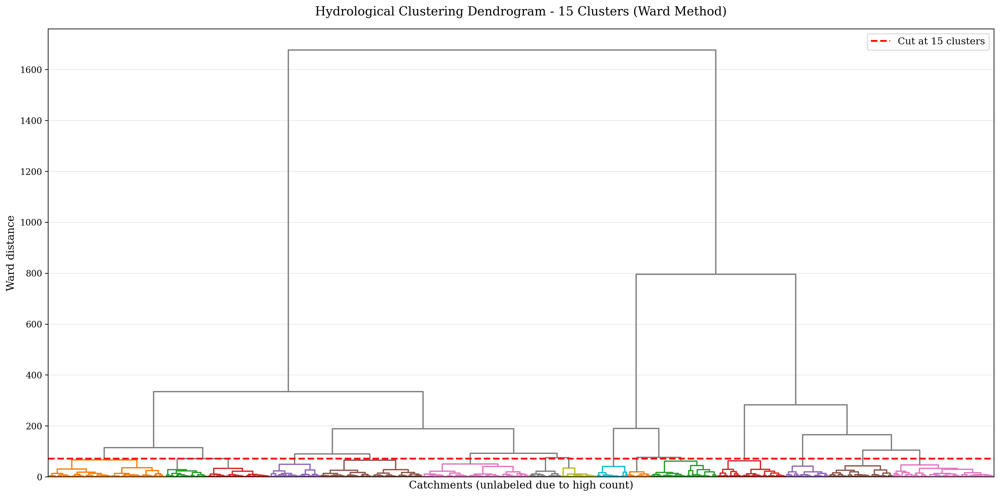

2025-10-10 15:56:48 | INFO     | camels_ru | hydrological_final | ℹ️  Hierarchical clustering complete: 15 clusters


In [6]:
# Perform hierarchical clustering using Ward's method
n_hydro_clusters = 15

Z = linkage(q_df_clust.values, method="ward", metric="euclidean")

# Create dendrogram
fig, ax = plt.subplots(figsize=(16, 8))
dendro = dendrogram(
    Z,
    ax=ax,
    above_threshold_color="#808080",
    color_threshold=Z[-n_hydro_clusters + 1, 2],
    no_labels=True,
    truncate_mode="level",
    p=0,
)

ax.set_xlabel("Catchments (unlabeled due to high count)", fontsize=12)
ax.set_ylabel("Ward distance", fontsize=12)
ax.set_title(
    f"Hydrological Clustering Dendrogram - {n_hydro_clusters} Clusters (Ward Method)",
    fontsize=14,
    pad=15,
)
ax.axhline(
    y=Z[-n_hydro_clusters + 1, 2],
    color="r",
    linestyle="--",
    linewidth=2,
    label=f"Cut at {n_hydro_clusters} clusters",
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

fig.savefig(
    f"../paper/images/dendrogram_ward_{n_hydro_clusters}_hydro_clusters.png",
    dpi=300,
    bbox_inches="tight",
)
plt.tight_layout()
plt.show()

logger.info(f"Hierarchical clustering complete: {n_hydro_clusters} clusters")

### 2.3 Extract Cluster Labels and Visualize Spatial Distribution

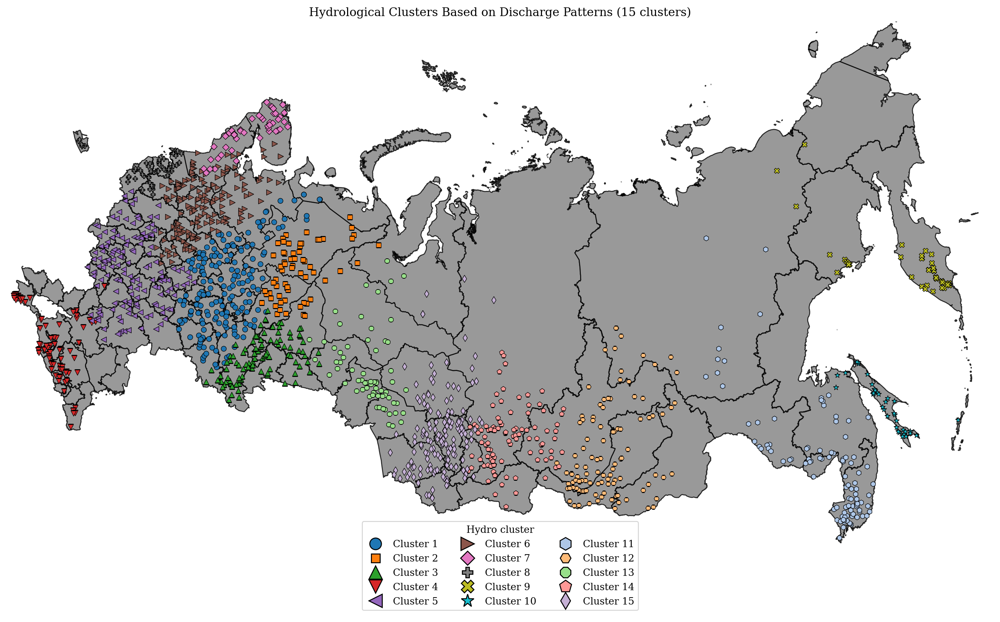

In [7]:
# Extract cluster labels using fcluster
hydro_labels = fcluster(Z, t=n_hydro_clusters, criterion="maxclust")

# Create GeoDataFrame with cluster assignments
gauge_hydro = gauge.loc[q_df_clust.index, :].copy()
gauge_hydro["hydro_cluster_id"] = hydro_labels
gauge_hydro["Hydro cluster"] = [f"Cluster {cl}" for cl in hydro_labels]

# Get colors and markers for visualization
markers_hc = get_cluster_markers(n_hydro_clusters)
colors_hc = get_cluster_colors(n_hydro_clusters)
marker_corrections = get_marker_size_corrections()

# Plot spatial distribution of hydrological clusters
fig_hydro_map = russia_plots(
    gdf_to_plot=gauge_hydro,
    basemap_data=basemap_data,
    distinction_col="Hydro cluster",
    markers_list=markers_hc,
    color_list=colors_hc,
    marker_size_corrections=marker_corrections,
    title_text=f"Hydrological Clusters Based on Discharge Patterns ({n_hydro_clusters} clusters)",
    figsize=(16, 9),
    just_points=True,
    legend_cols=3,
    base_marker_size=28,
    base_linewidth=0.5,
)
fig_hydro_map.savefig(
    f"../paper/images/hydro_clusters_{n_hydro_clusters}_map.png", dpi=300, bbox_inches="tight"
)
plt.show()

### 2.4 Visualize Hydrological Regime Types

Plot normalized seasonal discharge patterns for each hydrological cluster.

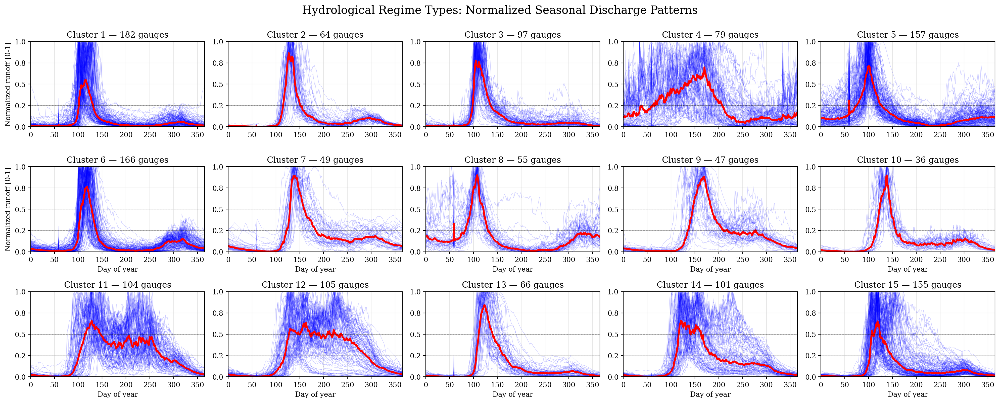

2025-10-10 15:56:55 | INFO     | camels_ru | hydrological_final | ℹ️  Hydrological regime visualization complete


In [8]:
# Prepare cluster-wise seasonal patterns
cluster_groups = list(gauge_hydro.groupby("Hydro cluster").groups.items())


def _cluster_num(key):
    """Extract numeric cluster ID from cluster name."""
    m = re.search(r"\d+", key)
    return int(m.group()) if m else float("inf")


cluster_groups_sorted = sorted(cluster_groups, key=lambda x: _cluster_num(x[0]))

# Build OrderedDict of cluster patterns
cluster_q_mm = OrderedDict()
for clust_name, member_ids in cluster_groups_sorted:
    clust_df = q_df_normalized.loc[:, member_ids].copy()
    clust_df.index = pd.date_range(start="2000-01-01", periods=366)
    cluster_q_mm[clust_name] = clust_df

# Create grid layout for 10 clusters (2 rows x 5 cols)
nrows = 3
ncols = 5

q_fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 8))
axes_flat = axes.flatten()

for i, (clust_name, clust_data) in enumerate(cluster_q_mm.items()):
    if i >= len(axes_flat):
        break
    clust_ax = axes_flat[i]

    # Calculate daily median across all gauges in cluster
    mean_by_gauge = (
        clust_data.groupby([clust_data.index.month, clust_data.index.day])
        .median()
        .reset_index(drop=True)
    )
    clust_avg = mean_by_gauge.median(axis=1).values.ravel()

    # Plot individual gauges (faint) and cluster median (red)
    for gauge_id in mean_by_gauge.columns:
        clust_ax.plot(
            mean_by_gauge.index.values,
            mean_by_gauge[gauge_id].values,
            color="blue",
            alpha=0.2,
            linewidth=0.5,
        )

    clust_ax.plot(
        mean_by_gauge.index.values,
        clust_avg,
        color="red",
        alpha=1.0,
        linewidth=2.5,
        label="Cluster median",
    )

    # Formatting
    clust_ax.grid(axis="both", which="both", alpha=0.3)
    clust_ax.set_xlim(0, 365)
    clust_ax.set_ylim(0, 1)
    clust_ax.set_yticks(np.arange(0, 1.25, 0.25))
    clust_ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    if i in [0, 5]:
        clust_ax.set_ylabel("Normalized runoff [0-1]")
    if i >= 5:
        clust_ax.set_xlabel("Day of year")

    for val in np.arange(0, 1.25, 0.25):
        clust_ax.axhline(val, c="black", linestyle="--", linewidth=0.2)

    clust_ax.set_title(f"{clust_name} — {len(clust_data.columns)} gauges")

# Turn off any unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")

q_fig.suptitle("Hydrological Regime Types: Normalized Seasonal Discharge Patterns", fontsize=16, y=1.00)
q_fig.tight_layout()
q_fig.savefig(
    f"../paper/images/hydrograph_clusters_{n_hydro_clusters}.png", dpi=300, bbox_inches="tight"
)
plt.show()

logger.info("Hydrological regime visualization complete")

## 3. Comprehensive Hydrological Metrics Calculation


### 3.1.1 Parallel Metrics Calculation (Optimized)

The parallel version uses multiprocessing to distribute calculations across CPU cores, significantly improving performance for large gauge networks.

**Performance comparison:**
- Sequential (original): ~10-15 minutes for 2000 gauges
- Parallel (8 workers): ~2-3 minutes (5-7× faster)

In [9]:
from src.hydro.parallel_metrics import calculate_metrics_parallel

# Calculate metrics in parallel (much faster than sequential loop)
all_metrics_parallel = calculate_metrics_parallel(
    discharge_data=discharge_data,
    gauge_ids=hydro_index,
    n_workers=12,  # Adjust based on your CPU (use cpu_count() - 1)
    period_type="hydrological",
    hydro_year_start_month=10,
    min_data_fraction=0.7,
    min_periods=5,
    aggregation="mean",
    show_progress=True,
)

# Convert to DataFrame
metrics_df = pd.DataFrame.from_dict(all_metrics_parallel, orient="index")
metrics_df = metrics_df.dropna(thresh=5)

Calculating metrics: 100%|██████████| 1463/1463 [00:00<00:00, 9368346.19it/s]



## 4. Trend Analysis Using Mann-Kendall Test

### 4.1 Calculate Trends for Annual Mean Discharge

Apply Mann-Kendall test and Sen's slope estimator to detect monotonic trends.

In [10]:
# Calculate trend statistics for each gauge
trend_results = {}

for gauge_id, discharge in discharge_data.items():
    try:
        # Resample to annual mean
        annual_discharge = discharge.resample("YE").mean()

        if len(annual_discharge) < 5:
            logger.warning(
                f"Insufficient data for trend analysis: {gauge_id} ({len(annual_discharge)} years)"
            )
            continue

        # Perform trend analysis using TrendAnalysis class
        trend_analyzer = TrendAnalysis(annual_discharge, variable_name="discharge")
        linear_trend = trend_analyzer.linear_trend()

        trend_results[gauge_id] = {
            "trend_slope": linear_trend["slope"],
            "trend_per_decade": linear_trend["trend_per_decade"],
            "trend_pvalue": linear_trend["p_value"],
            "trend_direction": linear_trend["trend_direction"],
            "trend_significant": linear_trend["trend_significant"],
            "r_squared": linear_trend["r_squared"],
            "n_years": linear_trend["n_observations"],
        }

    except Exception as e:
        logger.error(f"Error in trend analysis for {gauge_id}: {e}")
        continue

# Convert to DataFrame
trend_df = pd.DataFrame.from_dict(trend_results, orient="index")


## 5. Merge All Data for Comparative Analysis

### 5.1 Combine Metrics, Trends, and Cluster Assignments

In [32]:
# Merge metrics and trends
complete_df = metrics_df.join(trend_df, how="outer")

# Merge with gauge geometry
gauge_analysis = gauge.join(complete_df, how="inner")

# Add hydrological cluster information
gauge_analysis = gauge_analysis.join(gauge_hydro[["hydro_cluster_id", "Hydro cluster"]], how="left")

# Add geographical cluster information
gauge_analysis = gauge_analysis.join(geo_cluster_info, how="left")

# Add watershed area
gauge_analysis = gauge_analysis.join(ws[["area"]], how="left")

print(f"Complete analysis dataset: {len(gauge_analysis)} gauges")
print(f"\nColumns ({len(gauge_analysis.columns)}): ")
print(gauge_analysis.columns.tolist()[:15], "...")
print("\nCluster coverage:")
print(f"  Hydrological clusters: {gauge_analysis['hydro_cluster_id'].notna().sum()} gauges")
print(f"  Geographical clusters: {gauge_analysis['geo_cluster_id'].notna().sum()} gauges")

Complete analysis dataset: 1463 gauges

Columns (33): 
['name_ru', 'name_en', 'geometry', 'mean_discharge', 'median_discharge', 'std_discharge', 'total_discharge', 'cv_discharge', 'fdc_slope', 'q05', 'q50', 'q95', 'baseflow_index', 'high_flow_frequency', 'high_flow_avg_duration'] ...

Cluster coverage:
  Hydrological clusters: 1463 gauges
  Geographical clusters: 1461 gauges


## 6. Comparative Analysis: Geo Clusters vs Hydrological Metrics

### 6.1 Statistical Summary by Geographical Cluster

In [66]:
# Select key hydrological metrics for comparison (limit to 6 for plots)
key_metrics = [
    "mean_discharge",
    "q95",
    "q05",
    "baseflow_index",
    "mean_half_flow_date",
    "fdc_slope",
    "high_flow_frequency",
    "low_flow_frequency",
]

# Calculate statistics by geographical cluster
geo_cluster_stats = gauge_analysis.groupby("geo_cluster_name")[key_metrics].agg(
    ["mean", "median", "std", "count"]
)

print("Hydrological metrics by geographical cluster:")
print("=" * 80)
print(geo_cluster_stats)

# Save to CSV for paper
geo_cluster_stats.to_csv("../paper/tables/geo_cluster_hydro_stats.csv")
logger.info("Saved geographical cluster statistics to CSV")

2025-10-10 16:45:47 | INFO     | camels_ru | hydrological_final | ℹ️  Saved geographical cluster statistics to CSV


Hydrological metrics by geographical cluster:
                                     mean_discharge                            \
                                               mean    median       std count   
geo_cluster_name                                                                
Cropland (64.0%) / Clay-rich               0.294175  0.238740  0.506852   137   
Forested (57.4%)                           0.521641  0.514754  0.295156   166   
Forested (68.7%) / Sandy                   1.031662  0.940787  0.677120    83   
Forested (77.9%) / Permafrost              0.973104  0.824334  0.651697    50   
Forested (78.8%) / High-PET                1.506199  1.165939  1.181176    34   
Forested (84.1%) / Karst                   0.947155  0.874967  0.478790   170   
Forested (88.8%) / Snow-dominated          0.901185  0.809215  0.514610   379   
Highland (2215m) / Deep-GW                 1.471979  1.401220  0.764656    21   
Karst (82.7%) / Clay-rich                  0.781792  0.452478  

### 6.2 Trend Analysis by Geographical Cluster

In [67]:
# Analyze trends by geographical cluster
trend_by_geo = gauge_analysis.groupby("geo_cluster_name").agg(
    {
        "trend_per_decade": ["mean", "median", "std"],
        "trend_significant": "sum",
        "trend_direction": lambda x: x.value_counts().to_dict(),
    }
)

print("\nTrend analysis by geographical cluster:")
print("=" * 80)
print(trend_by_geo)

# Calculate percentage of gauges with significant trends per cluster
gauge_analysis["trend_sig_pct"] = gauge_analysis.groupby("geo_cluster_name")[
    "trend_significant"
].transform(lambda x: 100 * x.sum() / len(x))

trend_summary = gauge_analysis.groupby("geo_cluster_name").agg(
    {
        "trend_per_decade": "mean",
        "trend_significant": ["sum", "count"],
        "trend_sig_pct": "first",
    }
)
trend_summary.columns = ["_".join(col).strip() for col in trend_summary.columns]

print("\nTrend summary (% significant):")
print(trend_summary.sort_values("trend_sig_pct_first", ascending=False))

# Save to CSV
trend_summary.to_csv("../paper/tables/geo_cluster_trend_summary.csv")
logger.info("Saved trend summary by geographical cluster")

2025-10-10 16:45:51 | INFO     | camels_ru | hydrological_final | ℹ️  Saved trend summary by geographical cluster



Trend analysis by geographical cluster:
                                     trend_per_decade                      \
                                                 mean    median       std   
geo_cluster_name                                                            
Cropland (64.0%) / Clay-rich                -0.002682 -0.008742  0.096867   
Forested (57.4%)                             0.004477 -0.029027  0.187463   
Forested (68.7%) / Sandy                     0.070942  0.063030  0.297619   
Forested (77.9%) / Permafrost               -0.005284 -0.027640  0.174090   
Forested (78.8%) / High-PET                  0.187072  0.042915  0.793833   
Forested (84.1%) / Karst                     0.019997  0.010587  0.297450   
Forested (88.8%) / Snow-dominated           -0.007876 -0.018293  0.200906   
Highland (2215m) / Deep-GW                  -0.135692 -0.087065  0.296071   
Karst (82.7%) / Clay-rich                    0.022094  0.022888  0.272021   
Lowland (228m) / Moderate (493mm/yr

## 7. Publication-Quality Visualizations

### 7.1 Spatial Maps of Key Hydrological Metrics

**Updates to `russia_continuous_multiplot`:**

The plotting function has been completely reworked with the following improvements:

1. **Manual bin intervals**: Define custom intervals via `bin_intervals` dict (no auto-rounding)
2. **NaN handling**: Missing values shown as tiny black dots (size=4) instead of large circles
3. **Default marker size**: Reduced to 12 (was 18)
4. **Histogram/colorbar style**: Matches `russia_plots` layout
   - Histogram at bottom-left with colored bars
   - No x-axis labels on histogram
   - Y-axis shows occurrence counts
   - Bar colors aligned with colorbar

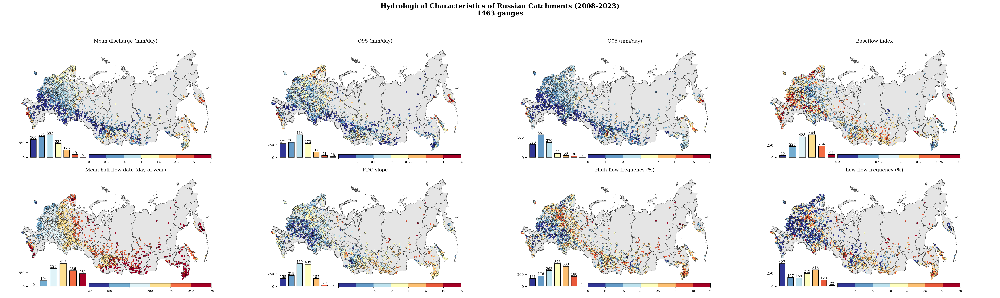

In [91]:
# English titles for metrics
metric_titles_en = [
    "Mean discharge (mm/day)",
    "Q95 (mm/day)",
    "Q05 (mm/day)",
    "Baseflow index",
    "Mean half flow date (day of year)",
    "FDC slope",
    "High flow frequency (%)",
    "Low flow frequency (%)",
]

# Define custom bin intervals for each metric
bin_intervals = {
    "mean_discharge": [(0, 0.3), (0.3, 0.6), (0.6, 1.0), (1.0, 1.5), (1.5, 2.5), (2.5, 5.0), (5.0, 8.0)],
    "q95": [(0, 0.05), (0.05, 0.1), (0.1, 0.2), (0.2, 0.35), (0.35, 0.6), (0.6, 1.0), (1.0, 2.5)],
    "q05": [(0, 1), (1, 3), (3, 5), (5, 7), (7, 10), (10, 15), (15, 20)],
    "baseflow_index": [
        (0.2, 0.35),
        (0.35, 0.45),
        (0.45, 0.55),
        (0.55, 0.65),
        (0.65, 0.75),
        (0.75, 0.85),
    ],
    "mean_half_flow_date": [
        (120.0, 150.0),
        (150.0, 180.0),
        (180.0, 200.0),
        (200.0, 220.0),
        (220.0, 240.0),
        (240.0, 270.0),
    ],
    "fdc_slope": [(0, 1.0), (1.0, 1.5), (1.5, 2.5), (2.5, 4.0), (4.0, 6.0), (6.0, 10.0), (10.0, 15.0)],
    "high_flow_frequency": [(0, 10), (10, 15), (15, 20), (20, 25), (25, 30), (30, 40), (40, 50)],
    "low_flow_frequency": [(0, 2), (2, 5), (5, 10), (10, 20), (20, 35), (35, 50), (50, 70)],
}

# Create multi-panel spatial plot (6 metrics, 2x3 grid) with custom intervals
fig_multiplot = russia_continuous_multiplot(
    gdf_to_plot=gauge_analysis,
    basemap_data=basemap_data,
    metrics=key_metrics,
    titles=metric_titles_en,
    main_title=(
        f"Hydrological Characteristics of Russian Catchments (2008-2023)\n{len(gauge_analysis)} gauges"
    ),
    bin_intervals=bin_intervals,  # Custom intervals instead of auto-generated bins
    cmap_name="RdYlBu_r",
    ncols=4,
    subplot_size=(8.0, 5.0),
    with_histogram=True,
    marker_size=12,  # Decreased from 15 to 12
)

# Save and display the figure
fig_multiplot.savefig(
    "../paper/images/hydrological_metrics_multiplot_8panels.png", dpi=300, bbox_inches="tight"
)
display(fig_multiplot)


### 7.2 Trend Maps

In [109]:
# Create categorical trend direction map
gauge_analysis["trend_category"] = gauge_analysis["trend_direction"].map(
    {
        "increasing": "Increasing",
        "decreasing": "Decreasing",
        "no trend": "No trend",
    }
)

# Mark significant trends
gauge_analysis["trend_significance"] = gauge_analysis.apply(
    lambda row: f"{row['trend_category']} (p<0.05)"
    if row["trend_significant"]
    else f"{row['trend_category']} (n.s.)",
    axis=1,
)


trend_cats = sorted(gauge_analysis["trend_significance"].dropna().unique())
gauge_analysis.dropna(subset=["trend_significance"])

,name_ru,name_en,geometry,mean_discharge,median_discharge,std_discharge,total_discharge,cv_discharge,fdc_slope,q05,...,r_squared,n_years,hydro_cluster_id,Hydro cluster,geo_cluster_id,geo_cluster_name,area,trend_sig_pct,trend_category,trend_significance
78224,р.Арчеда - х.Нижнянский,r.Archeda - h.Nizhnjanskij,POINT (43.16629 49.87651),0.082684,0.052774,0.127783,28.608557,1.082285,1.129570,0.232987,...,0.082572,16,5,Cluster 5,1.0,Cropland (64.0%) / Clay-rich,1635.726761,15.217391,Decreasing,Decreasing (n.s.)
80442,р.Ворскла - с.Козинка,r.Vorskla - s.Kozinka,POINT (35.58991 50.46952),0.192100,0.150728,0.153503,64.671935,0.804158,1.377417,0.509489,...,0.163960,16,5,Cluster 5,1.0,Cropland (64.0%) / Clay-rich,1871.224395,15.217391,Decreasing,Decreasing (n.s.)
5238,р.Комиссаровка - пос.Дворянка,r.Komissarovka - pos.Dvorjanka,POINT (131.59849 44.88848),0.475997,0.197318,0.708881,160.271043,1.277817,4.067890,1.881936,...,0.191605,9,11,Cluster 11,9.0,Forested (88.8%) / Snow-dominated,1174.229285,6.578947,Increasing,Increasing (n.s.)
5354,р.Кия - пос.Переяславка,r.Kija - pos.Perejaslavka,POINT (135.05475 47.9517),0.839982,0.488536,1.154991,298.286634,1.280523,3.299449,2.759885,...,0.009995,16,11,Cluster 11,12.0,Forested (84.1%) / Karst,989.712381,11.176471,Increasing,Increasing (n.s.)
5765,р. Арсеньевка - с. Яковлевка *,r. Arsen'evka - s. Jakovlevka *,POINT (133.52626 44.43575),0.989854,0.427509,1.345296,338.148087,1.344256,3.486801,4.034895,...,0.001585,11,11,Cluster 11,9.0,Forested (88.8%) / Snow-dominated,5278.201342,6.578947,Increasing,Increasing (n.s.)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10204,р.Бердь - пгт Маслянино,r.Berd' - pgt Masljanino,POINT (84.22121 54.34582),0.760722,0.454364,1.184714,263.853430,1.516700,1.367702,2.455357,...,0.274649,16,15,Cluster 15,12.0,Forested (84.1%) / Karst,2531.534000,11.176471,Increasing,Increasing (p<0.05)
10246,р.Томь - г.Кемерово,r.Tom' - g.Kemerovo,POINT (86.13008 55.364),1.742381,0.853416,2.316260,625.358032,1.320491,3.067104,6.942620,...,0.037468,14,15,Cluster 15,12.0,Forested (84.1%) / Karst,47373.177000,11.176471,Decreasing,Decreasing (n.s.)
10387,р.Кия - г.Мариинск,r.Kija - g.Mariinsk,POINT (87.77199 56.21137),1.177036,0.434333,1.841786,413.071747,1.554096,2.817968,5.358138,...,0.034213,16,15,Cluster 15,9.0,Forested (88.8%) / Snow-dominated,10563.537000,6.578947,Decreasing,Decreasing (n.s.)
11350,р.Тара - с.Верхняя Тарка,r.Tara - s.Verhnjaja Tarka,POINT (77.50132 56.62805),0.251898,0.108961,0.329574,87.810580,1.259750,2.742403,1.141772,...,0.231224,16,13,Cluster 13,8.0,Sandy / Snow-dominated,6554.609000,8.955224,Decreasing,Decreasing (n.s.)


In [114]:
get_cluster_markers(n_trend_cats)


['o', 's', '^', 'v']

In [117]:
marker_corrections


{'o': 1.0,
 '^': 1.15,
 'v': 1.15,
 '<': 1.15,
 '>': 1.15,
 'd': 1.0,
 'p': 1.05,
 'h': 1.05,
 'H': 0.95,
 '8': 1.0,
 'X': 1.1,
 '*': 1.2,
 'D': 0.85,
 'P': 0.9,
 's': 0.8}

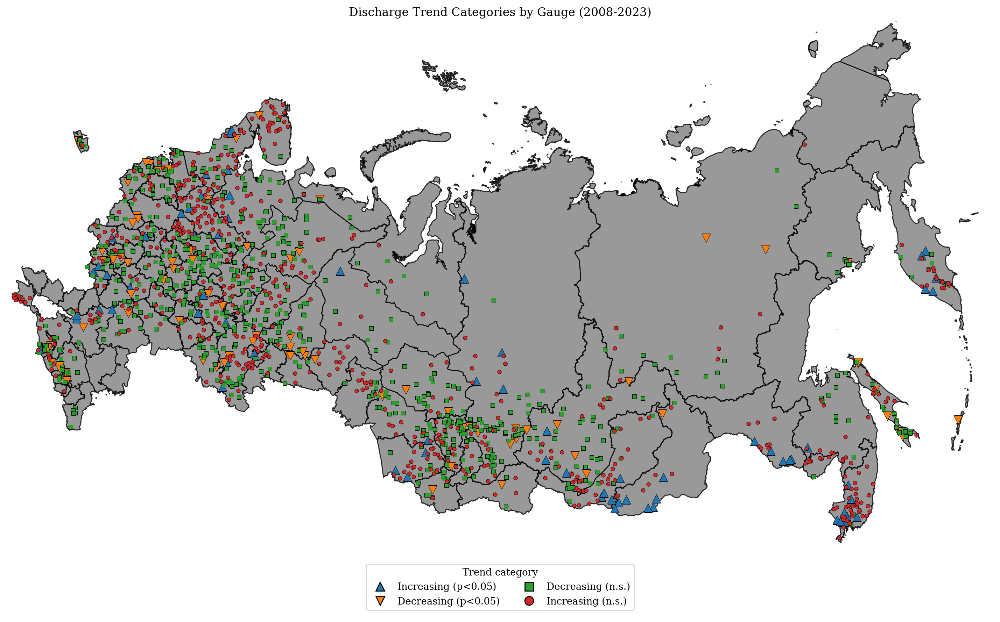

In [127]:
n_trend_cats = len(trend_cats)
trend_colors = get_cluster_colors(n_trend_cats)
trend_markers = ["^", "v", "s", "o"]
marker_corrections = get_marker_size_corrections()
marker_corrections = {"^": 2.0, "v": 2.0, "s": 0.4, "o": 0.4}
gauge_analysis.rename(columns={"trend_significance": "Trend category"}, inplace=True)

fig_trend_cat = russia_plots(
    gdf_to_plot=gauge_analysis.dropna(subset=["Trend category"]),
    basemap_data=basemap_data,
    distinction_col="Trend category",
    title_text="Discharge Trend Categories by Gauge (2008-2023)",
    figsize=(16, 9),
    just_points=True,
    legend_cols=2,
    markers_list=trend_markers,
    color_list=trend_colors,
    marker_size_corrections=marker_corrections,
    base_marker_size=40,
)
fig_trend_cat.savefig("../paper/images/trend_categories_map.png", dpi=300, bbox_inches="tight")

### 7.3 Box Plots: Metrics by Geographical Cluster

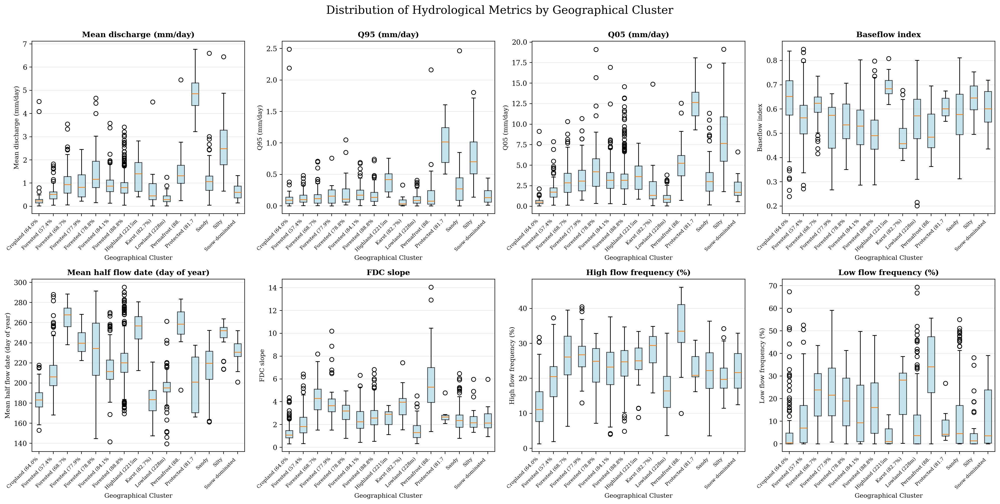

2025-10-10 17:17:27 | INFO     | camels_ru | hydrological_final | ℹ️  Saved box plots by geographical cluster


In [128]:
# Box plots for key metrics by geographical cluster
fig_box, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, metric in enumerate(key_metrics):
    ax = axes[idx]

    # Prepare data for boxplot
    data_to_plot = []
    labels = []
    for cluster_name in sorted(gauge_analysis["geo_cluster_name"].dropna().unique()):
        cluster_data = gauge_analysis[gauge_analysis["geo_cluster_name"] == cluster_name][
            metric
        ].dropna()
        if len(cluster_data) > 0:
            data_to_plot.append(cluster_data)
            # Shorten cluster name for x-axis
            short_name = cluster_name.split("/")[0].strip()[:15]
            labels.append(short_name)

    bp = ax.boxplot(
        data_to_plot,
        labels=labels,
        patch_artist=True,
        showfliers=True,
    )

    # Color boxes
    for patch in bp["boxes"]:
        patch.set_facecolor("lightblue")
        patch.set_alpha(0.7)

    ax.set_title(metric_titles_en[idx], fontsize=11, fontweight="bold")
    ax.set_xlabel("Geographical Cluster", fontsize=9)
    ax.set_ylabel(metric_titles_en[idx], fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.sca(ax)
    plt.xticks(rotation=45, ha="right", fontsize=7)

fig_box.suptitle("Distribution of Hydrological Metrics by Geographical Cluster", fontsize=16, y=1.00)
plt.tight_layout()
fig_box.savefig("../paper/images/metrics_by_geo_cluster_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

logger.info("Saved box plots by geographical cluster")

## 8. Export Results for Paper

### 8.1 Save Complete Dataset

In [129]:
# Export complete analysis results
gauge_analysis.to_file("../results/hydrological_analysis_complete.gpkg", driver="GPKG")

# Export as CSV (without geometry)
gauge_analysis_csv = gauge_analysis.drop(columns=["geometry"])
gauge_analysis_csv.to_csv("../results/hydrological_analysis_complete.csv")

print("Exported complete analysis:")
print("  - GeoPackage: ../results/hydrological_analysis_complete.gpkg")
print("  - CSV: ../results/hydrological_analysis_complete.csv")
print(f"  - Gauges: {len(gauge_analysis)}")
print(f"  - Attributes: {len(gauge_analysis.columns)}")

logger.info("Analysis results exported successfully")

2025-10-10 17:17:38 | INFO     | camels_ru | hydrological_final | ℹ️  Analysis results exported successfully


Exported complete analysis:
  - GeoPackage: ../results/hydrological_analysis_complete.gpkg
  - CSV: ../results/hydrological_analysis_complete.csv
  - Gauges: 1463
  - Attributes: 36


### 8.2 Create Summary Tables for Paper

In [130]:
# Create directory for paper tables if it doesn't exist
Path("../paper/tables").mkdir(parents=True, exist_ok=True)

# Table 1: Overall statistics
overall_stats = pd.DataFrame(
    {
        "Metric": metric_titles_en,
        "Mean": [gauge_analysis[m].mean() for m in key_metrics],
        "Median": [gauge_analysis[m].median() for m in key_metrics],
        "Std": [gauge_analysis[m].std() for m in key_metrics],
        "Min": [gauge_analysis[m].min() for m in key_metrics],
        "Max": [gauge_analysis[m].max() for m in key_metrics],
        "N": [gauge_analysis[m].notna().sum() for m in key_metrics],
    }
)
overall_stats.to_csv("../paper/tables/overall_hydro_statistics.csv", index=False)
print("\nTable 1: Overall Statistics")
print("=" * 100)
print(overall_stats.to_string(index=False))

# Table 2: Hydrological cluster summary
hydro_cluster_summary = gauge_analysis.groupby("Hydro cluster").agg(
    {
        "mean_discharge": ["mean", "std"],
        "baseflow_index": ["mean", "std"],
        "trend_per_decade": ["mean", "std"],
        "trend_significant": "sum",
        "hydro_cluster_id": "count",
    }
)
hydro_cluster_summary.columns = ["_".join(col).strip() for col in hydro_cluster_summary.columns]
hydro_cluster_summary.to_csv("../paper/tables/hydro_cluster_summary.csv")
print("\nTable 2: Hydrological Cluster Summary")
print("=" * 100)
print(hydro_cluster_summary)

logger.info("Created summary tables for paper")

2025-10-10 17:17:40 | INFO     | camels_ru | hydrological_final | ℹ️  Created summary tables for paper



Table 1: Overall Statistics
                           Metric       Mean     Median       Std        Min        Max    N
          Mean discharge (mm/day)   0.856908   0.672560  0.793244   0.017926   7.012224 1456
                     Q95 (mm/day)   0.185136   0.130096  0.219123   0.000676   2.490509 1456
                     Q05 (mm/day)   2.937679   2.299014  2.654050   0.041863  23.010496 1456
                   Baseflow index   0.554515   0.558124  0.111902   0.200753   0.846945 1456
Mean half flow date (day of year) 216.980638 213.847222 28.148605 139.533333 295.416667 1440
                        FDC slope   2.505167   2.277168  1.433698   0.305574  14.058964 1456
          High flow frequency (%)  21.447329  22.100048  7.681907   1.305399  46.095972 1456
           Low flow frequency (%)  13.948275   9.247943 14.347210   0.000000  69.396987 1456

Table 2: Hydrological Cluster Summary
               mean_discharge_mean  mean_discharge_std  baseflow_index_mean  \
Hydro cluster   